# Figure 3: Energy Fraction vs Pulse Width (Simplified)
### Reproducing Figure 3 from Romallosa et al. (2003)

This notebook reproduces **Figure 3** from the paper:
> "Three-dimensional light distribution near the focus of a tightly focused beam of few-cycle optical pulses"
> Romallosa, K.M., Bantang, J., Saloma, C. *Phys. Rev. A* **68**, 033812 (2003)

**Figure 3 shows:** Fraction of energy (relative to total pulse energy) contained within the FWHM of the central spot of the transverse intensity distribution (at z=0) as a function of pulsewidth τ.

**Simple Energy Fraction Calculation:**
```python
energy_fraction = np.sum(I[I >= 0.5 * np.max(I)]) / np.sum(I)
```

This counts all intensity within the FWHM region (≥50% of peak) divided by total intensity.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import sys
import warnings
warnings.filterwarnings('ignore')

# Add the package to path
sys.path.append('../src')

# Import optical diffraction package
from optical_diffraction import (
    OpticalSystem, 
    PulsedBeam,
    pulsed_richards_wolf_diffraction
)

print("Successfully imported optical diffraction package!")
print(f"Python version: {sys.version}")

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

Successfully imported optical diffraction package!
Python version: 3.8.16 | packaged by conda-forge | (default, Feb  1 2023, 16:01:13) 
[Clang 14.0.6 ]


In [44]:
# Define paper parameters (Romallosa et al. 2003)
LAMBDA_C = 750e-9  # Central wavelength: 750 nm
SIN_ALPHA = 0.8    # sin α = 0.8 (fixed for this figure)
N_MEDIUM = 1.3     # Refractive index of medium

# NA values from the paper (12 values)
NA_VALUES = np.array([0.1, 0.8])

# Pulse width range (fs) - log spacing like in the paper
TAU_VALUES = [1,2,3,4,5,10]

# Calculation parameters
N_FREQUENCIES = 201  # Number of spectral components (as in paper)
N_RADIAL = 301       # Number of radial points for good FWHM resolution

print(f"Central wavelength: {LAMBDA_C*1e9:.0f} nm")
print(f"NA values: {NA_VALUES}")
print(f"Pulse width range: {TAU_VALUES[0]:.2f} - {TAU_VALUES[-1]:.2f} fs")
print(f"Total calculations: {len(NA_VALUES)} × {len(TAU_VALUES)} = {len(NA_VALUES) * len(TAU_VALUES)}")

Central wavelength: 750 nm
NA values: [0.1 0.8]
Pulse width range: 1.00 - 10.00 fs
Total calculations: 2 × 6 = 12


In [33]:
TAU_VALUES

[1, 2, 5, 10]

In [45]:
def calculate_energy_fraction_simple(na_value, tau_fs):
    """
    Calculate energy fraction using the simple method:
    energy_fraction = sum(I[I >= 0.5*max(I)]) / sum(I)
    
    Parameters
    ----------
    na_value : float
        Numerical aperture
    tau_fs : float
        Pulse width in femtoseconds
        
    Returns
    -------
    energy_fraction : float
        Fraction of energy within FWHM
    """
    try:
        # Create optical system
        system = OpticalSystem(
            wavelength=LAMBDA_C,
            numerical_aperture=na_value,
            refractive_index=N_MEDIUM
        )
        
        # Create pulsed beam
        tau_seconds = tau_fs * 1e-15  # Convert fs to seconds
        pulsed_beam = PulsedBeam(
            center_wavelength=LAMBDA_C,
            pulse_width_fwhm=tau_seconds,
        )
        
        # Create radial coordinates for transverse profile at focus (z=0)
        r_range = 6 * system.airy_radius  # Sufficient range to capture beam
        r_coords = np.linspace(-r_range, r_range, N_RADIAL)
        z_coords = np.zeros_like(r_coords)  # At focus (z = 0)
        
        # Calculate pulsed intensity distribution
        Ex, Ey, Ez = pulsed_richards_wolf_diffraction(
            system=system,
            pulsed_beam=pulsed_beam,
            r_coords=r_coords,
            z_coords=z_coords,
            n_frequencies=N_FREQUENCIES,
            addition_method='incoherent',  # Follows Romallosa eq. (10)
            n_processes=1
        )
        
        # Total intensity (for incoherent addition, Ex, Ey, Ez are already intensities)
        I_total = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
        
        # Simple energy fraction calculation
        max_intensity = np.max(I_total)
        half_max = 0.5 * max_intensity
        
        # Energy in FWHM region (I >= 0.5 * max) / Total energy
        energy_in_fwhm = np.sum(I_total[I_total >= half_max])
        total_energy = np.sum(I_total)
        
        if total_energy == 0:
            return np.nan
            
        energy_fraction = energy_in_fwhm / total_energy
        
        return energy_fraction
        
    except Exception as e:
        print(f"Error for NA={na_value}, τ={tau_fs} fs: {e}")
        return np.nan

print("Energy fraction calculation function defined")

Energy fraction calculation function defined


In [47]:
# # Test the calculation with a single point
# print("Testing calculation with NA=0.8, τ=1.0 fs...")
# test_result = calculate_energy_fraction_simple(0.8, 1.0)
# print(f"Test result: {test_result:.4f}")

# if np.isnan(test_result) or test_result == 0:
#     print("\nError in test calculation. Please check the implementation.")
# else:
#     print("\nTest successful! Proceeding with full calculation...")

In [48]:
# Calculate energy fractions for all combinations
print("Calculating energy fractions for all NA and pulse width combinations...")
print("This may take several minutes...\n")

# Store results in lists for DataFrame
results_data = []

# Calculate for each combination
for na in tqdm(NA_VALUES, desc="NA values"):
    for tau in tqdm(TAU_VALUES, desc=f"τ values (NA={na:.1f})", leave=False):
        energy_fraction = calculate_energy_fraction_simple(na, tau)
        
        results_data.append({
            'NA': na,
            'Pulse_Width_fs': tau,
            'Energy_Fraction': energy_fraction
        })

# Create DataFrame
df = pd.DataFrame(results_data)

print("\nCalculation complete!")
print(f"Total data points: {len(df)}")
print(f"Valid results: {df['Energy_Fraction'].notna().sum()}")
print(f"NaN results: {df['Energy_Fraction'].isna().sum()}")

# Show sample results
print("\nSample results:")
print(df.head(10))

Calculating energy fractions for all NA and pulse width combinations...
This may take several minutes...



NA values:   0%|          | 0/2 [00:00<?, ?it/s]




Computing I0 integral: 100%|██████████| 301/301 [00:00<00:00, 306.67it/s]






Computing I1 integral: 100%|██████████| 301/301 [00:01<00:00, 238.63it/s]




Computing I2 integral: 100%|██████████| 301/301 [00:01<00:00, 297.55it/s]





Computing I0 integral: 100%|██████████| 301/301 [00:01<00:00, 297.83it/s]




Computing I1 integral: 100%|██████████| 301/301 [00:00<00:00, 314.72it/s]




Computing I2 integral: 100%|██████████| 301/301 [00:01<00:00, 291.67it/s]





Computing I0 integral: 100%|██████████| 301/301 [00:00<00:00, 301.23it/s]




Computing I1 integral: 100%|██████████| 301/301 [00:01<00:00, 288.41it/s]




Computing I2 integral: 100%|██████████| 301/301 [00:01<00:00, 268.82it/s]





Computing I0 integral: 100%|██████████| 301/301 [00:00<00:00, 321.41it/s]




Computing I1 integral: 100%|██████████| 301/301 [00:01<00:00, 299.58it/s]




Computing I2 integral: 100%|██████████| 301/301 [00:00<00:00, 334.80it/s]





Compu

KeyboardInterrupt: 

In [49]:
import os

In [ ]:
# Configuration
results_file = "energy_fraction_results.csv"
save_every = 1  # Save progress every N calculations

# Load existing results
if os.path.exists(results_file):
    df_existing = pd.read_csv(results_file)
    print(f"Loaded {len(df_existing)} existing results")
else:
    df_existing = pd.DataFrame(columns=['NA', 'Pulse_Width_fs', 'Energy_Fraction'])
    print("Starting fresh - no existing results found")

# Find combinations that need to be calculated
pending_calculations = []
for na in NA_VALUES:
    for tau in TAU_VALUES:
        # Check if this combination already exists
        mask = (df_existing['NA'] == na) & (df_existing['Pulse_Width_fs'] == tau)
        if not any(mask):
            pending_calculations.append((na, tau))

print(f"Found {len(pending_calculations)} calculations to perform")
print(f"Skipping {len(NA_VALUES) * len(TAU_VALUES) - len(pending_calculations)} existing calculations")

# Perform calculations
if len(pending_calculations) > 0:
    new_results = []
    
    for i, (na, tau) in enumerate(tqdm(pending_calculations, desc="Calculating energy fractions")):
        try:
            energy_fraction = calculate_energy_fraction_simple(na, tau)
            new_results.append({
                'NA': na,
                'Pulse_Width_fs': tau,
                'Energy_Fraction': energy_fraction
            })
        except Exception as e:
            print(f"Error calculating NA={na}, τ={tau}: {e}")
            new_results.append({
                'NA': na,
                'Pulse_Width_fs': tau,
                'Energy_Fraction': np.nan
            })
        
        # Save progress periodically
        if (i + 1) % save_every == 0:
            df_temp = pd.concat([df_existing, pd.DataFrame(new_results)], ignore_index=True)
            df_temp.to_csv(results_file, index=False)
            print(f"Progress saved: {i+1}/{len(pending_calculations)} complete")
    
    # Final save
    df_final = pd.concat([df_existing, pd.DataFrame(new_results)], ignore_index=True)
    df_final.to_csv(results_file, index=False)
    
    print(f"\nCalculation complete!")
    print(f"New calculations: {len(new_results)}")
    print(f"Total results: {len(df_final)}")
else:
    df_final = df_existing
    print("All calculations already complete!")

# Show results
df = df_final

<Axes: xlabel='Pulse_Width_fs', ylabel='Energy_Fraction'>

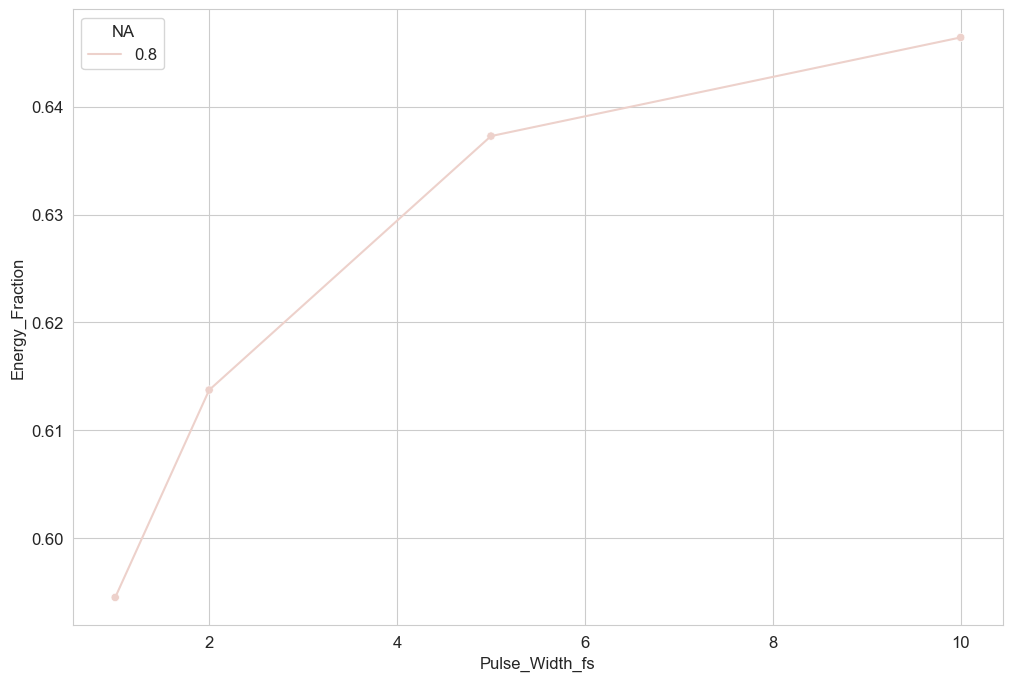

In [42]:
sns.scatterplot(data=df_clean, x="Pulse_Width_fs", y="Energy_Fraction", hue="NA", style="NA", legend=False)
sns.lineplot(data=df_clean, x="Pulse_Width_fs", y="Energy_Fraction", hue="NA", style="NA")